# CMPT 353 Project - Heart Failure Prediction

## The Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# First let's read the CSV into a DataFrame
file_path = 'heart.csv'
heart_df = pd.read_csv(file_path)

In [3]:
heart_df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [4]:
# Displaying basic info...
info = heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
# Displaying statistical summary...
description = heart_df.describe(include='all')
description

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


# Cleaning The Data

## Checking null and NaN values

In [6]:
cleaned_heart_df = heart_df.copy()

# Check for missing values
print('Checking existence of null values')
print(cleaned_heart_df.isnull().sum())

print('-----------------------------------')

# Check for NaN values
print('Checking existence of NaN values')
print(cleaned_heart_df.isna().sum())

Checking existence of null values
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
-----------------------------------
Checking existence of NaN values
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


## Checking for Duplicate Rows

In [7]:
duplicate_rows = cleaned_heart_df[cleaned_heart_df.duplicated()]

# Display duplicate rows
print("Duplicate Rows except first occurrence:")
print(duplicate_rows)

# Count the number of duplicate rows
print("\nNumber of duplicate rows:", len(duplicate_rows))

Duplicate Rows except first occurrence:
Empty DataFrame
Columns: [Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS, RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope, HeartDisease]
Index: []

Number of duplicate rows: 0


# Visualizing The Relationship of Each Variable With Heart Disease

## Binary Categorical Variables

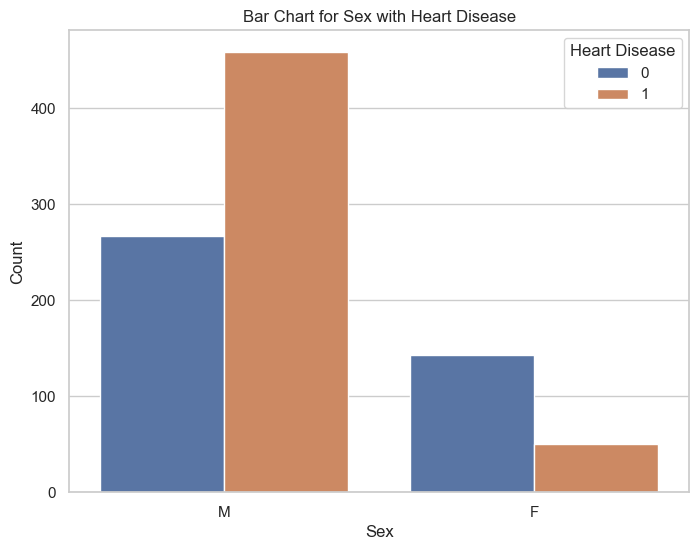

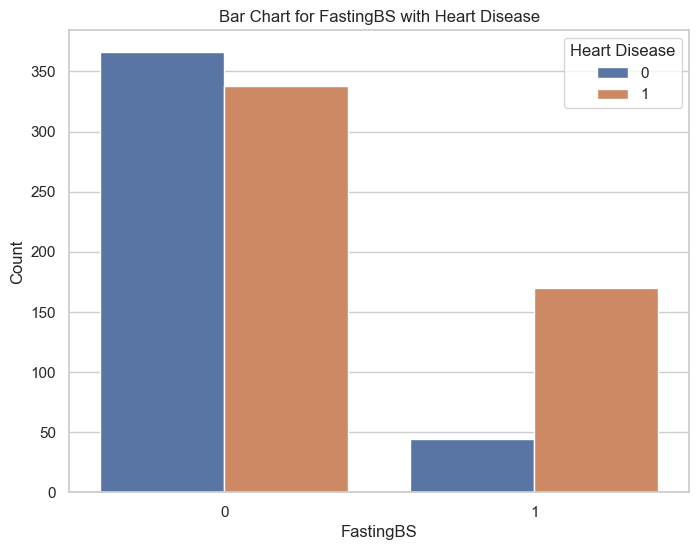

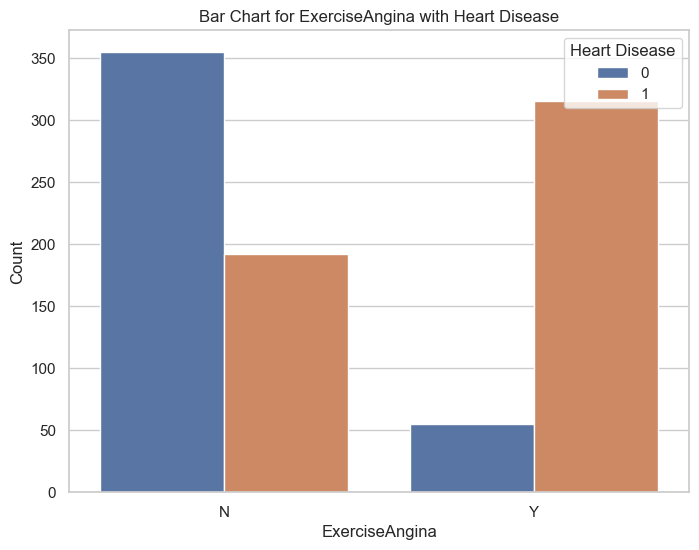

In [8]:
# Selecting binary categorical variables
binary_categorical_vars = ['Sex', 'FastingBS', 'ExerciseAngina']

sns.set(style='whitegrid')

# Plotting bar charts for binary categorical variables
for var in binary_categorical_vars:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=var, hue='HeartDisease', data=heart_df)
    plt.title(f'Bar Chart for {var} with Heart Disease')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.legend(title='Heart Disease', loc='upper right')
    plt.show()


## Non-binary Categorical Variables

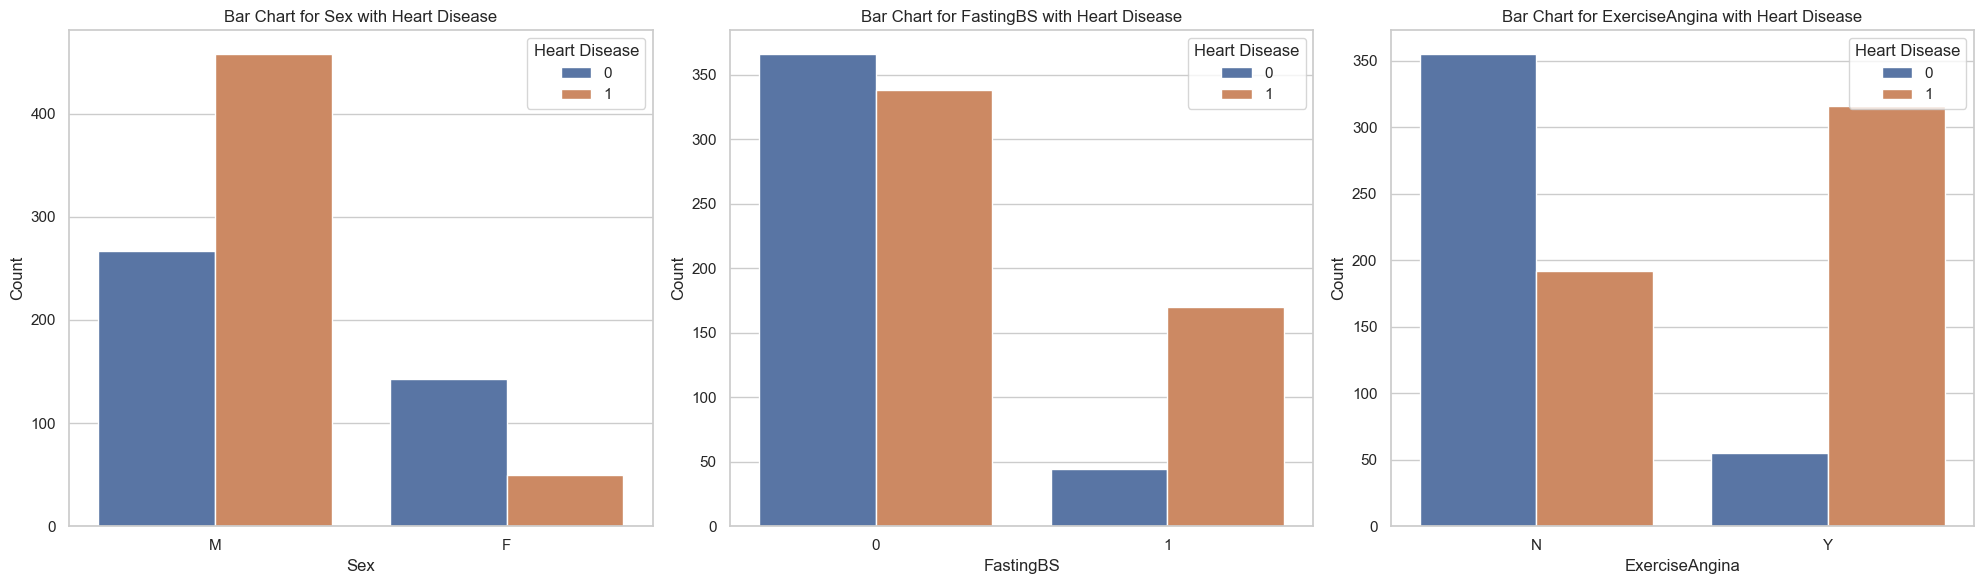

In [9]:
# Selecting binary categorical variables
binary_categorical_vars = ['Sex', 'FastingBS', 'ExerciseAngina']

# Creating a single figure for all bar charts
fig, axes = plt.subplots(nrows=1, ncols=len(binary_categorical_vars), figsize=(20, 6))

sns.set(style='whitegrid')

# Plotting bar charts for binary categorical variables
for i, var in enumerate(binary_categorical_vars):
    sns.countplot(x=var, hue='HeartDisease', data=heart_df, ax=axes[i])
    axes[i].set_title(f'Bar Chart for {var} with Heart Disease')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Heart Disease', loc='upper right')

plt.tight_layout()
plt.show()

## Histograms for Numerical Variables

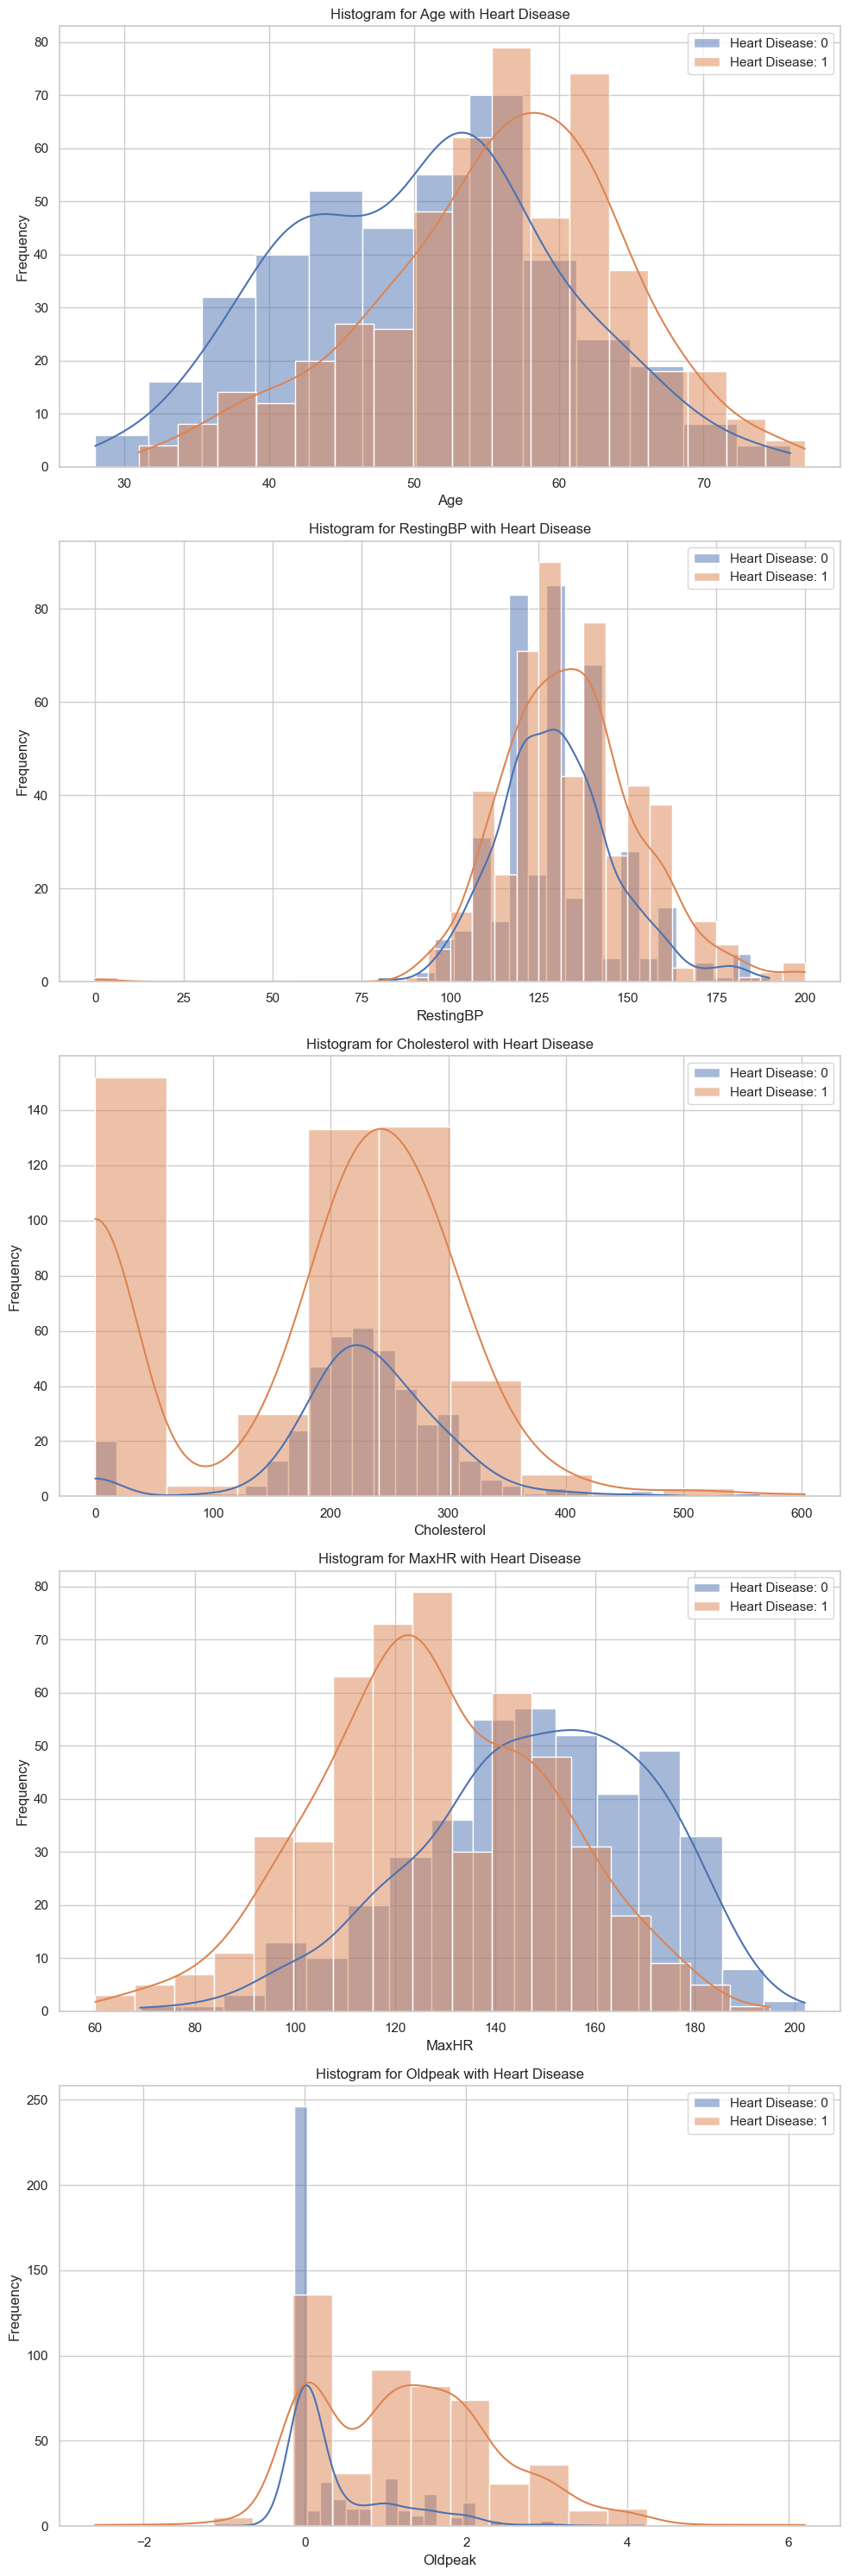

In [10]:
# Selecting numerical variables
numerical_vars = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Creating a single figure for all histograms
fig, axes = plt.subplots(nrows=len(numerical_vars), ncols=1, figsize=(10, 6 * len(numerical_vars)))

# Plotting histograms for numerical variables
for i, var in enumerate(numerical_vars):
    # Plotting histograms for each category of HeartDisease
    for heart_disease_category in heart_df['HeartDisease'].unique():
        sns.histplot(heart_df[heart_df['HeartDisease'] == heart_disease_category][var], kde=True, label=f'Heart Disease: {heart_disease_category}', ax=axes[i])

    axes[i].set_title(f'Histogram for {var} with Heart Disease')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

# Adjusting layout
plt.tight_layout()
plt.show()


## Pie Chart for the Balance of Target Variable (Heart Disease)

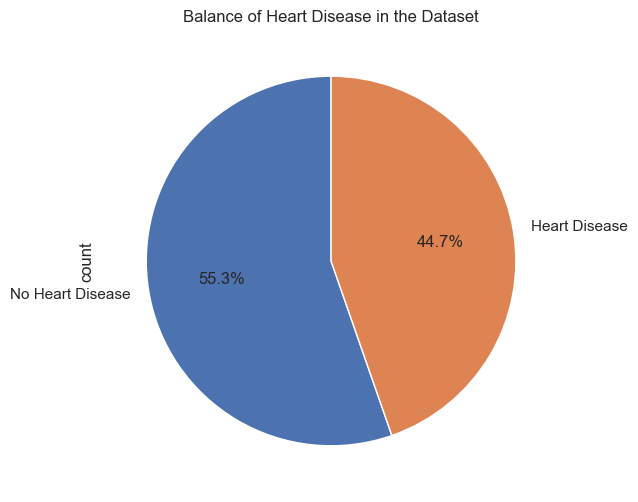

In [11]:
# Plotting a pie chart for the balance of the target variable
sns.set(style='whitegrid')
plt.figure(figsize=(6, 6))
heart_df['HeartDisease'].value_counts().plot.pie(autopct='%1.1f%%', labels=['No Heart Disease', 'Heart Disease'], startangle=90)
plt.title('Balance of Heart Disease in the Dataset')
plt.show()